# Road Following - Live demo

In this notebook, we will use model we trained to move jetBot smoothly on track. 

### Load Trained Model

We will assume that you have already downloaded ``best_steering_model_xy.pth`` to work station as instructed in "train_model.ipynb" notebook. Now, you should upload model file to JetBot in to this notebook's directory. Once that's finished there should be a file named ``best_steering_model_xy.pth`` in this notebook's directory.

> Please make sure the file has uploaded fully before calling the next cell

Execute the code below to initialize the PyTorch model. This should look very familiar from the training notebook.

In [1]:
MODEL_PATH = 'models/dataset_labeled_2/model_to_import.pth'

In [ ]:
import torchvision
import torch

model = torchvision.models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
model.load_state_dict(torch.load(MODEL_PATH))
#model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Next, load the trained weights from the ``best_steering_model_xy.pth`` file that you uploaded.

In [ ]:
# model.load_state_dict(torch.load(MODEL_PATH))

<All keys matched successfully>

Currently, the model weights are located on the CPU memory execute the code below to transfer to the GPU device.

In [ ]:
device = torch.device('cuda')
model = model.to(device)
model = model.eval().half()

dummy = torch.zeros(1, 3, 224, 224).to(device).half()
with torch.no_grad():
    model = torch.jit.trace(model, dummy)
    for _ in range(20):
        model(dummy)

print('Model ready')

### Creating the Pre-Processing Function

We have now loaded our model, but there's a slight issue. The format that we trained our model doesn't exactly match the format of the camera. To do that, we need to do some preprocessing. This involves the following steps:

1. Convert from HWC layout to CHW layout
2. Normalize using same parameters as we did during training (our camera provides values in [0, 255] range and training loaded images in [0, 1] range so we need to scale by 255.0
3. Transfer the data from CPU memory to GPU memory
4. Add a batch dimension

In [ ]:
import torchvision.transforms as transforms
import torch.nn.functional as F
import cv2
import PIL.Image
import numpy as np

mean = torch.Tensor([0.485, 0.456, 0.406]).cuda().half()
std = torch.Tensor([0.229, 0.224, 0.225]).cuda().half()

mean_cpu = torch.tensor([0.485, 0.456, 0.406])
std_cpu  = torch.tensor([0.229, 0.224, 0.225])

def preprocess(image):
    image = PIL.Image.fromarray(image)
    image = transforms.functional.to_tensor(image).to(device).half()
    image.sub_(mean[:, None, None]).div_(std[:, None, None])
    return image[None, ...]

def preprocess_cpu(image):
    # dokładnie jak live_demo, tylko bez cuda i half

    if isinstance(image, PIL.Image.Image):
        image = np.array(image)

    image = PIL.Image.fromarray(image)

    tensor = transforms.functional.to_tensor(image)

    tensor.sub_(mean_cpu[:, None, None])
    tensor.div_(std_cpu[:, None, None])

    return tensor.unsqueeze(0)

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def predict_xy_cpu(image):
    tensor = preprocess_cpu(image)
    with torch.no_grad():
        xy = model(tensor).detach().cpu().numpy().flatten()
    return xy

mean_gpu = torch.Tensor([0.485, 0.456, 0.406]).cuda().half()
std_gpu  = torch.Tensor([0.229, 0.224, 0.225]).cuda().half()

#   CHANGED PREPROCESSING TO AVOID PIL CONVERSION, AS CAMERA ALREADY GIVES US NUMPY HWC BGR =============================================================================
# def preprocess_gpu(image):
#     if isinstance(image, PIL.Image.Image):
#         image = np.array(image)
#     image = PIL.Image.fromarray(image)
#     tensor = transforms.functional.to_tensor(image).to(device).half()
#     tensor.sub_(mean_gpu[:, None, None]).div_(std_gpu[:, None, None])
#     return tensor.unsqueeze(0)

def preprocess_gpu(image):
    # image is already a numpy HWC BGR array from the camera
    tensor = torch.from_numpy(image).permute(2, 0, 1).float()  # HWC→CHW
    tensor = tensor[[2, 1, 0]]          # BGR→RGB
    tensor = tensor.to(device).half()
    tensor.div_(255.0)
    tensor.sub_(mean_gpu[:, None, None]).div_(std_gpu[:, None, None])
    return tensor.unsqueeze(0)

def predict_xy_gpu(image):
    tensor = preprocess_gpu(image)
    with torch.no_grad():
        xy = model(tensor).squeeze()
    return float(xy[0]), float(xy[1])

def compute_wheel_output(
    xy,
    speed_gain=0.2,
    steering_gain=0.2,
    steering_bias=0.0,
    steering_dgain=0.0,
    angle_last=0.0,
):
    x = xy[0] - 0.5
    y = 1.0 - xy[1]
    angle = np.arctan2(x, y)

    pid = angle * steering_gain + (angle - angle_last) * steering_dgain
    steering = pid + steering_bias

    # steering = speed_gain * steering_gain * angle + steering_bias
    
    left  = float(np.clip(speed_gain + steering, 0.0, 1.0))
    right = float(np.clip(speed_gain - steering, 0.0, 1.0))
    return {
        'x':       float(xy[0]),
        'y':       float(xy[1]),
        'angle':   float(angle),
        'steering': float(steering),
        'left':    left,
        'right':   right,
    }

ModuleNotFoundError: No module named 'cv2'

Awesome! We've now defined our pre-processing function which can convert images from the camera format to the neural network input format.

Now, let's start and display our camera. You should be pretty familiar with this by now. 

In [ ]:
from IPython.display import display
import ipywidgets
import traitlets
from jetbot import Camera, bgr8_to_jpeg

camera = Camera()

image_widget = ipywidgets.Image()

traitlets.dlink((camera, 'value'), (image_widget, 'value'), transform=bgr8_to_jpeg)

display(image_widget)

We'll also create our robot instance which we'll need to drive the motors.

In [ ]:
from jetbot import Robot

robot = Robot()

# Steering

#### For steering we have the sliders 
    Suggested values (speed=0.2, steering=0.05)

#### Also we have an arctan2 function for angle calculation

This uses the parameter 'curvature' in the formula np.arctan2(x*curvature,y)
where a controls curvature (higher a ->more curved function)

In [ ]:
speed_gain_slider = ipywidgets.FloatSlider(min=0.0, max=1.0, step=0.2, description='speed gain')
steering_gain_slider = ipywidgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.05, description='steering gain')
steering_dgain_slider = ipywidgets.FloatSlider(min=0.0, max=0.5, step=0.001, value=0.0, description='steering kd')
steering_bias_slider = ipywidgets.FloatSlider(min=-0.3, max=0.3, step=0.01, value=0.0, description='steering bias')

display(speed_gain_slider, steering_gain_slider, steering_dgain_slider, steering_bias_slider)

In [ ]:
# x_slider = ipywidgets.FloatSlider(min=-1.0, max=1.0, description='x')
# y_slider = ipywidgets.FloatSlider(min=0, max=1.0, orientation='vertical', description='y')
# steering_slider = ipywidgets.FloatSlider(min=-1.0, max=1.0, description='steering')
# speed_slider = ipywidgets.FloatSlider(min=0, max=1.0, orientation='vertical', description='speed')

# display(ipywidgets.HBox([y_slider, speed_slider]))
# display(x_slider, steering_slider)

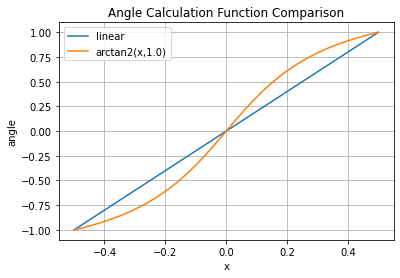

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def angle_calculation_function(x, y):
    curvature = 2
    value_at_max = np.arctan2(0.5*curvature, 0.5)  # arctan2(1, 1) gives us the angle at the point (1, 1)
    return np.arctan2(x*curvature, y) / value_at_max

#create a plot with different functions to compare with the original arctan2
fig = plt.figure()
plt.plot(np.linspace(-0.5, 0.5, 100), [x for x in np.linspace(-1, 1, 100)], label='linear')
plt.plot(np.linspace(-0.5, 0.5, 100), [angle_calculation_function(x, 1.0) for x in np.linspace(-1, 1, 100)], label='arctan2(x,1.0)')
plt.legend()
plt.title('Angle Calculation Function Comparison')
plt.xlabel('x')
plt.ylabel('angle')
plt.grid()
plt.show()

In [ ]:
# ALTERNATE STEERING LOGIC
angle = 0.0
angle_last = 0.0
current_steering = 0.0
ALPHA = 0.3
STRAIGHT_THRESHOLD = 0.05

def execute(change):
    global angle, angle_last, current_steering

    xy = predict_xy_gpu(change['new'])
    x  = xy[0] - 0.5
    y  = 1 - xy[1]
    angle = angle_calculation_function(x, y)

    pid = angle * steering_gain_slider.value + (angle - angle_last) * steering_dgain_slider.value
    angle_last = angle

    target_steering = 0.0 if abs(angle) < STRAIGHT_THRESHOLD else pid + steering_bias_slider.value

    # Smooth toward target instead of snapping
    current_steering = ALPHA * target_steering + (1 - ALPHA) * current_steering

    # x_slider.value       = x
    # y_slider.value       = y
    # speed_slider.value   = speed_gain_slider.value
    # steering_slider.value = current_steering

    left  = float(np.clip(speed_gain_slider.value + current_steering, 0.0, 1.0))
    right = float(np.clip(speed_gain_slider.value - current_steering, 0.0, 1.0))

    robot.left_motor.value  = left
    robot.right_motor.value = right

In [ ]:
while True:
    execute({'new': camera.value})

In [ ]:
import time

# camera.unobserve(execute, names='value')

time.sleep(0.1)  # add a small sleep to make sure frames have finished processing

robot.stop()

In [ ]:
camera.stop()